In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
print(df.shape)
print(df.head())

(891, 12)
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN    

In [ ]:
col = ["PassengerId", "Name", "Ticket", "Cabin"]
df = df.drop(columns = col)

In [3]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    str    
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  889 non-null    str    
dtypes: float64(2), int64(4), str(2)
memory usage: 55.8 KB
None


In [4]:
df['Pclass'] = df["Pclass"].astype(str)

In [5]:
df['Sex'] = df['Sex'].map({"male": 0, "female": 1})

In [6]:
print(df['Embarked'].value_counts())

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64


In [7]:
print(df['Survived'].value_counts())

Survived
0    549
1    342
Name: count, dtype: int64


In [8]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Survived'])
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
print(X_train.isnull().sum())

Pclass        0
Sex           0
Age         140
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64


In [10]:
age_median = X_train["Age"].median()
X_train["Age"] = X_train["Age"].fillna(age_median)
X_test["Age"] = X_test["Age"].fillna(age_median)

In [11]:
emb = X_train["Embarked"].mode()[0]
X_train["Embarked"] = X_train["Embarked"].fillna(age_median)
X_test["Embarked"] = X_test["Embarked"].fillna(age_median)

In [12]:
viz_df = pd.concat([X_train, y_train],axis = 1)


Text(0.5, 1.0, 'Coorelation Heatmap')

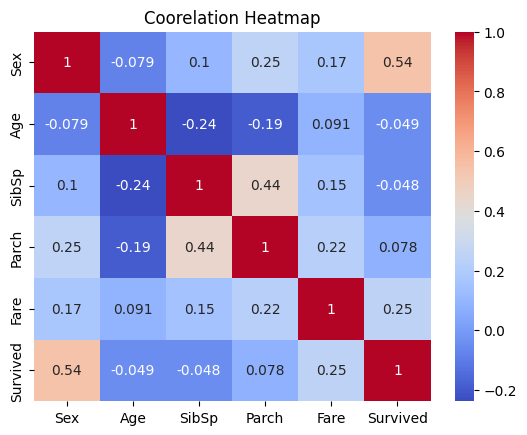

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = viz_df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot = True, cmap = 'coolwarm')
plt.title("Coorelation Heatmap")

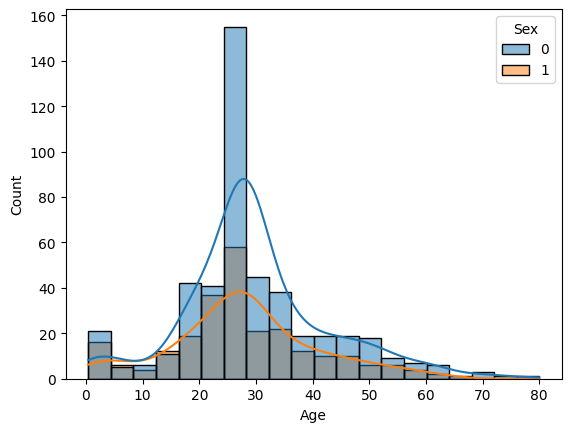

In [14]:
sns.histplot(data = viz_df, x = 'Age', hue = "Sex", bins = 20, kde = True)
plt.show()

In [15]:
X_train["Sex"] = X_train["Sex"].astype(str)
X_test['Sex'] = X_test['Sex'].astype(str)
X_train['Embarked'] = X_train['Embarked'].astype(str)
X_test['Embarked'] = X_test['Embarked'].astype(str)

In [16]:
numcols = X_train.select_dtypes(include = 'number').columns
print(numcols)
strcols = X_train.select_dtypes(include = 'str').columns
print(strcols)

Index(['Age', 'SibSp', 'Parch', 'Fare'], dtype='str')
Index(['Pclass', 'Sex', 'Embarked'], dtype='str')


In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numcols] = scaler.fit_transform(X_train_scaled[numcols])
X_test_scaled[numcols] = scaler.transform(X_test_scaled[numcols])

In [18]:
X_train_scaled = pd.get_dummies(X_train_scaled, columns= strcols, drop_first = True)
X_test_scaled = pd.get_dummies(X_test_scaled, columns=strcols, drop_first=True)

X_train_scaled, X_test_scaled = X_train_scaled.align(X_test_scaled, join = 'left', axis = 1, fill_value=0)


In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000, class_weight= "balanced" ),
    "Decision Tree": DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(random_state=42, class_weight="balanced")
}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    test_acc = accuracy_score(y_test, model.predict(X_test_scaled))
    train_acc = accuracy_score(y_train, model.predict(X_train_scaled))
    print(f"{name}: Test: {test_acc} | Train: {train_acc}")

Logistic Regression: Test: 0.8044692737430168 | Train: 0.7780898876404494
Decision Tree: Test: 0.7541899441340782 | Train: 0.9789325842696629
Random Forest: Test: 0.8212290502793296 | Train: 0.9789325842696629


In [20]:
from sklearn.metrics import classification_report

for name, model in models.items():
    print(name)
    print(classification_report(y_test, model.predict(X_test_scaled)))

Logistic Regression
              precision    recall  f1-score   support

           0       0.85      0.81      0.83       105
           1       0.75      0.80      0.77        74

    accuracy                           0.80       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.81      0.80      0.81       179

Decision Tree
              precision    recall  f1-score   support

           0       0.83      0.73      0.78       105
           1       0.67      0.78      0.72        74

    accuracy                           0.75       179
   macro avg       0.75      0.76      0.75       179
weighted avg       0.76      0.75      0.76       179

Random Forest
              precision    recall  f1-score   support

           0       0.83      0.87      0.85       105
           1       0.80      0.76      0.78        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82   

In [21]:
from sklearn.model_selection import cross_val_score

for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv = 5)
    print(f"{name}: {scores.mean()} +/- {scores.std()}")

Logistic Regression: 0.7738697921796514 +/- 0.012202109125192673
Decision Tree: 0.7485964739485865 +/- 0.014987523672590803
Random Forest: 0.7921796513345809 +/- 0.020131725305679415


In [22]:
rf_param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2,5]   
}

In [23]:
from sklearn.model_selection import GridSearchCV

grid = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight="balanced"),
    rf_param_grid,
    cv = 5,
    n_jobs = -1,
    scoring = 'accuracy'
)

grid.fit(X_train_scaled, y_train)
print(grid.best_params_)
print(grid.best_score_)
best_model =  grid.best_estimator_
print(best_model.score(X_test_scaled, y_test)) 

{'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200}
0.8202107751403526
0.8044692737430168


In [24]:
importances = pd.Series(best_model.feature_importances_, index = X_train_scaled.columns)
print(importances.sort_values())

Embarked_Q    0.007820
Embarked_C    0.015628
Pclass_2      0.015730
Embarked_S    0.024752
Parch         0.036742
SibSp         0.047967
Age           0.113029
Pclass_3      0.115820
Fare          0.174810
Sex_1         0.447700
dtype: float64


In [25]:
import joblib

joblib.dump(best_model, "Titanic.pkl")

['Titanic.pkl']

In [26]:
loaded_model = joblib.load("Titanic.pkl")
print(loaded_model.score(X_test_scaled, y_test))

0.8044692737430168


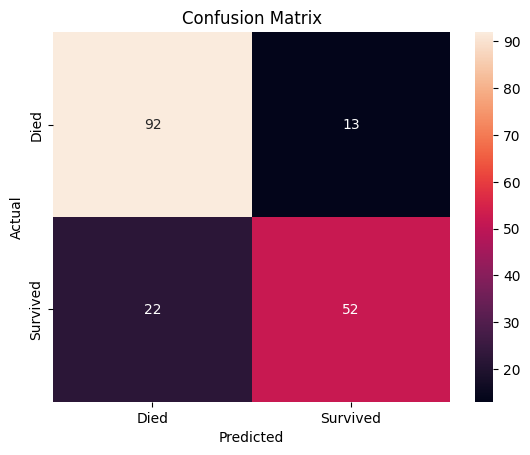

In [27]:
from sklearn.metrics import confusion_matrix

y_pred = loaded_model.predict(X_test_scaled)
cm =  confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot = True, fmt = 'd', xticklabels=["Died", "Survived"], yticklabels=["Died", "Survived"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [28]:
print(classification_report(y_test, best_model.predict(X_test_scaled)))

              precision    recall  f1-score   support

           0       0.81      0.88      0.84       105
           1       0.80      0.70      0.75        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179

